In [1]:
!pip install git+https://github.com/helpingstar/gym-snakegame.git


  Cloning https://github.com/helpingstar/gym-snakegame.git to /tmp/pip-req-build-o0e0iwum
  Running command git clone --filter=blob:none --quiet https://github.com/helpingstar/gym-snakegame.git /tmp/pip-req-build-o0e0iwum
  Resolved https://github.com/helpingstar/gym-snakegame.git to commit a809354855d274cf63c92b6be1d9aa8d050f1636
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# 1. Dependencies and Result Directories

In [2]:
import gymnasium as gym
import gym_snakegame
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import pickle

from rewards import SnakeRewardWrapper

In [3]:
os.makedirs("final_results/data", exist_ok=True)
os.makedirs("final_results/plots", exist_ok=True)
os.makedirs("final_results/models", exist_ok=True)

# 2. State Space Feature Engineering
Two distinct state representation strategies are implemented to go further the initial analysis and evaluate their impact on convergence and generalization: (for future work and possibilities)

In [4]:
def get_allocentric_state(env):
    snake = env.unwrapped.snake
    if len(snake) == 0: 
        return (0,) * 6
    
    board = env.unwrapped.board
    head = snake[-1] # Snake Head X/Y
    target_val = env.unwrapped.ITEM
    
    target_pos = np.argwhere(board == target_val)[0]
    
    momentum_map = {
        0: (-1, 0), 
        1: (0, 1), 
        2: (1, 0),  
        3: (0, -1) 
    }
    
    prev_action = env.unwrapped.prev_action
    momentum = momentum_map.get(prev_action, (0, 0))

    return (
        float(head[0]),      # Snake Head Y
        float(head[1]),      # Snake Head X
        float(target_pos[0]),# Food Y
        float(target_pos[1]),# Food X
        float(momentum[0]),  # Y Momentum
        float(momentum[1])   # X Momentum
    )

def get_egocentric_state(env):
    snake = env.unwrapped.snake
    if len(snake) == 0: return (0,)*6
        
    board = env.unwrapped.board
    head = snake[-1]
    target_val = env.unwrapped.ITEM
    bs = env.unwrapped.board_size
    target_pos = np.argwhere(board == target_val)[0]
    prev_action = env.unwrapped.prev_action 

    dirs = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
    curr_dir = dirs.get(prev_action, (0, 1)) 

    forward = curr_dir
    left = (-curr_dir[1], curr_dir[0])
    right = (curr_dir[1], -curr_dir[0])

    def is_unsafe(offset):
        r, c = head[0] + offset[0], head[1] + offset[1]
        if not (0 <= r < bs and 0 <= c < bs): return True
        return 0 < board[r, c] < target_val

    danger_straight = is_unsafe(forward)
    danger_left = is_unsafe(left)
    danger_right = is_unsafe(right)

    food_vec = (target_pos[0] - head[0], target_pos[1] - head[1])
    food_forward = np.sign(food_vec[0]*forward[0] + food_vec[1]*forward[1])
    food_lateral = np.sign(food_vec[0]*right[0] + food_vec[1]*right[1])

    return (danger_straight, danger_left, danger_right, food_forward, food_lateral, prev_action)

# 3. Tabular Q-Learning Algorithm
The `QLearningAgent` implements the standard Q-update rule:
$$Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s, a)]$$
* **Exploration:** $\epsilon$-greedy strategy with exponential decay.
* **Hyperparameters:** Discount factor ($\gamma = 0.95$).\
The learning rate is tuned to calibrate the speed of policy updates against the variance of the return signal across different reward regimes:

* In the **Survivalist** system ($+0.05$ per step) and **Dense** system ($-0.01$ per step), $\alpha$ is 0.1 because a higher learning rate lets the agent quickly learn from both step signals and bigger rewards.
* For the **Sparse** system, most steps give 0 reward. Using a smaller $\alpha$ avoids making huge jumps from the occasional +10 or -10.

In [5]:
class QLearningAgent:
    def __init__(self, action_space=4, alpha=0.1, gamma=0.95):
        self.q_table = {}
        self.action_space = action_space
        self.alpha = alpha
        self.gamma = gamma

    def choose_action(self, state_key, epsilon):
        if np.random.uniform(0, 1) < epsilon:
            return np.random.randint(self.action_space)
        q_values = [self.q_table.get((state_key, a), 0.0) for a in range(self.action_space)]
        return np.argmax(q_values)

    def update(self, state_key, action, reward, next_state_key):
        current_q = self.q_table.get((state_key, action), 0.0)
        max_next_q = max([self.q_table.get((next_state_key, a), 0.0) for a in range(self.action_space)])
        td_error = reward + self.gamma * max_next_q - current_q
        self.q_table[(state_key, action)] = current_q + self.alpha * td_error

# 4. Training Pipeline: Multi-Reward Experiments

In [6]:
experiments = [
    {"name": "Dense_Standard", "reward": "dense", "alpha": 0.1},
    {"name": "Sparse_Experimental", "reward": "sparse", "alpha": 0.05},
    {"name": "Survivalist_Safe", "reward": "survivalist", "alpha": 0.1}
]

In [11]:
state_representations = {"Allocentric": get_allocentric_state, "Egocentric": get_egocentric_state}

episodes = 50000
epsilon_start, epsilon_min, epsilon_decay = 1.0, 0.01, 0.9995
training_logs = {}

for state_name, state_func in state_representations.items():
    for exp in experiments:
        run_name = f"{state_name}_{exp['name']}"
        print(f"Initiating Training: {run_name}")
        
        base_env = gym.make("gym_snakegame/SnakeGame-v0", board_size=10)
        env = SnakeRewardWrapper(base_env, system_type=exp['reward'])
        
        agent = QLearningAgent(alpha=exp['alpha'])
        returns = []
        epsilon = epsilon_start
        
        for ep in tqdm(range(episodes), desc=f"Episodes ({run_name})"):
            env.reset(seed=42)
            state_key = str(state_func(env))
            done = False
            total_r = 0
            
            while not done:
                action = agent.choose_action(state_key, epsilon)
                _, reward, terminated, truncated, _ = env.step(action)
                next_state_key = str(state_func(env))
                
                agent.update(state_key, action, reward, next_state_key)
                state_key = next_state_key
                total_r += reward
                done = terminated or truncated
                
            epsilon = max(epsilon_min, epsilon * epsilon_decay)
            returns.append(total_r)
            
        training_logs[run_name] = returns
        with open(f"final_results/models/{run_name}_q_table.pkl", "wb") as f:
            pickle.dump(agent.q_table, f)

Initiating Training: Allocentric_Dense_Standard


Episodes (Allocentric_Dense_Standard):   0%|          | 0/50000 [00:00<?, ?it/s]

Initiating Training: Allocentric_Sparse_Experimental


Episodes (Allocentric_Sparse_Experimental):   0%|          | 0/50000 [00:00<?, ?it/s]

Initiating Training: Allocentric_Survivalist_Safe


...

Episodes (Egocentric_Dense_Standard):   0%|          | 0/50000 [00:00<?, ?it/s]

Initiating Training: Egocentric_Sparse_Experimental


Episodes (Egocentric_Sparse_Experimental):   0%|          | 0/50000 [00:00<?, ?it/s]

Initiating Training: Egocentric_Survivalist_Safe


Episodes (Egocentric_Survivalist_Safe):   0%|          | 0/50000 [00:00<?, ?it/s]

# 5. Learning Curves & Convergence

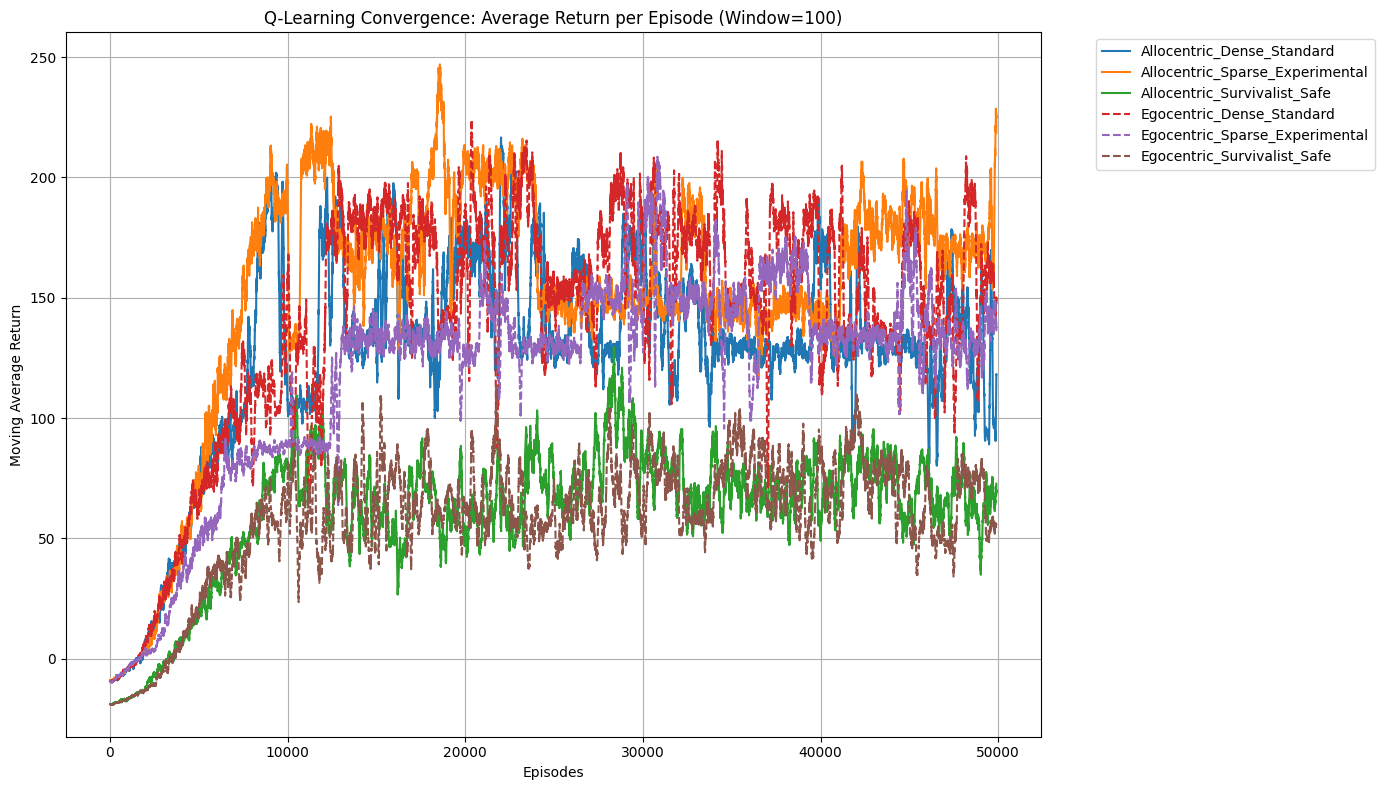

In [12]:
plt.figure(figsize=(14, 8))
for name, returns in training_logs.items():
    smoothed = np.convolve(returns, np.ones(100)/100, mode='valid')
    linestyle = '-' if 'Allocentric' in name else '--'
    plt.plot(smoothed, label=name, linestyle=linestyle)

plt.title("Q-Learning Convergence: Average Return per Episode (Window=100)")
plt.xlabel("Episodes")
plt.ylabel("Moving Average Return")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig('final_results/plots/q_learning_training_curves.png')
plt.show()